In [17]:
import os
import xarray as xr
import glob
import rioxarray
import rasterio
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shapely.geometry import box

In [18]:
# Folder path
folder = '/global/scratch/users/yougsanghvi/era5_daily_by_year/'

# Use glob to get all matching files
all_files = glob.glob(folder + 'era5_daily_mean_*.nc')

# Filter for years 2000-2004 only
files_2000_2004 = [f for f in all_files if any(str(year) in f for year in range(2000, 2005))]

# Load and concatenate
ds_era5 = xr.open_mfdataset(files_2000_2004, combine='by_coords')

print(ds_era5)


/tmp/ipykernel_3266966/1106996912.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_era5 = xr.open_mfdataset(files_2000_2004, combine='by_coords')
/tmp/ipykernel_3266966/1106996912.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_era5 = xr.open_mfdataset(files_2000_2004, combine='by_coords')


<xarray.Dataset> Size: 8GB
Dimensions:    (time: 1827, latitude: 721, longitude: 1440)
Coordinates:
    number     int64 8B 0
    step       timedelta64[ns] 8B 00:00:00
    surface    float64 8B 0.0
  * latitude   (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude  (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
  * time       (time) datetime64[ns] 15kB 2000-01-01 2000-01-02 ... 2004-12-31
Data variables:
    t2m        (time, latitude, longitude) float32 8GB dask.array<chunksize=(366, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2025-07-10T10:21 GRIB to CDM+CF via cfgrib-0.9.1...


/tmp/ipykernel_3266966/1106996912.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_era5 = xr.open_mfdataset(files_2000_2004, combine='by_coords')
/tmp/ipykernel_3266966/1106996912.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_era5 = xr.open_mfdataset(files_2000_2004, combine='by_coords')
/tmp/ipykernel_3266966/1106996912.py:11: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ds_era5 = xr.open_mfdataset(files_2000_2004, combine='by_coords')


In [20]:
gdnat_path = '/global/scratch/users/yougsanghvi/gdnat_1979-2020.nc'
ds_gdnat = xr.open_dataset(gdnat_path)
ds_gdnat_sub = ds_gdnat.sel(time=slice('2000-01-01', '2004-12-31'))
print(ds_gdnat_sub)

<xarray.Dataset> Size: 8GB
Dimensions:  (model: 1, time: 1825, lat: 720, lon: 1440)
Coordinates:
  * lat      (lat) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75
  * lon      (lon) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * model    (model) <U10 40B 'ACCESS-CM2'
  * time     (time) object 15kB 2000-01-01 00:00:00 ... 2004-12-31 00:00:00
Data variables:
    tas      (model, time, lat, lon) float32 8GB ...
Attributes:
    Created by:     Robert Fofrich <robertfofrich@ucla.edu>
    Creation date:  Compiled ZARR store created and saved 2025-02-11 01:39:52...
    Description:    GDNat: a global, daily, high-resolution natural-forcing o...
    Method:         Use Quantile Delta Mapping to apply quantile-by-quantile ...
    Repo:           https://github.com/ClimateImpactLab/gdnat
    Source files:   gs://impactlab-data/climate/attribution/outputs/hist-nat-...


In [24]:
# Select model 'ACCESS-CM2' and subset time
ds_gdnat_sub = ds_gdnat.sel(model='ACCESS-CM2', time=slice('2000-01-01', '2004-12-31'))

# Rename spatial dims and set CRS for GDNat
ds_gdnat_sub = ds_gdnat_sub.rename({'lat': 'y', 'lon': 'x'})
ds_gdnat_sub = ds_gdnat_sub.rio.write_crs("EPSG:4326")

# --- 3. Load US counties shapefile ---
shp_path = '/global/scratch/users/yougsanghvi/tl_2016_us_county_mortality.shp'
counties = gpd.read_file(shp_path)
counties = counties.to_crs("EPSG:4326")

# --- 4. Clip datasets to US counties ---
ds_era5_usa = ds_era5.rio.clip(counties.geometry, counties.crs, drop=True)
ds_gdnat_usa = ds_gdnat_sub.rio.clip(counties.geometry, counties.crs, drop=True)

# --- 5. Compute daily temperature difference and average over time ---
temp_diff = ds_era5_usa['t2m'] - ds_gdnat_usa['tas']
diff_avg = temp_diff.mean(dim='time')

ERROR 1: PROJ: internal_proj_create_from_database: /global/software/rocky-8.x86_64/gcc/linux-rocky8-x86_64/gcc-11.4.0/proj-9.2.1-bbhelefiajxgp4kdvlkru6cicfl3ty5t/share/proj/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


In [ ]:

# --- 6. Plot average difference with county outlines ---
fig, ax = plt.subplots(figsize=(14, 10))

diff_avg.plot(
    ax=ax,
    cmap='coolwarm',
    cbar_kwargs={'label': 'Temperature Difference (K)'}
)

counties.boundary.plot(
    ax=ax,
    edgecolor='black',
    linewidth=0.5,
    alpha=0.7
)

# Zoom to USA extent
ax.set_xlim(counties.total_bounds[[0, 2]])
ax.set_ylim(counties.total_bounds[[1, 3]])

ax.set_title("Average Temperature Difference (ERA5 - GDNat), 2000-2004 USA")
plt.show()

In [13]:
temp_gdnat

<xarray.DataArray (time: 5, band: 365, y: 720, x: 1440)> Size: 8GB
array([[[[243.64174, 243.64174, 243.64174, ..., 243.64174, 243.64174,
          243.64174],
         [244.04518, 244.04585, 244.0464 , ..., 244.00575, 244.00624,
          244.00673],
         [244.17886, 244.2178 , 244.2189 , ..., 244.1769 , 244.17795,
          244.17862],
         ...,
         [259.85205, 260.0597 , 260.0667 , ..., 259.83783, 259.84265,
          259.847  ],
         [259.8628 , 260.06775, 260.0725 , ..., 259.8529 , 259.85638,
          259.85944],
         [258.4838 , 258.48605, 258.4882 , ..., 258.58032, 258.5821 ,
          258.58386]],

        [[243.29076, 243.29076, 243.29076, ..., 243.29076, 243.29076,
          243.29076],
         [243.12817, 243.12805, 243.1278 , ..., 243.11496, 243.11447,
          243.1141 ],
         [242.99744, 243.01053, 243.0101 , ..., 243.00317, 243.0022 ,
          243.00043],
...
         [251.45662, 251.40486, 251.4016 , ..., 251.46516, 251.46217,
          251.45938],
         [251.49507, 251.48009, 251.47865, ..., 251.50111, 251.49904,
          251.49702],
         [251.5479 , 251.54713, 251.54645, ..., 251.56386, 251.56264,
          251.56142]],

        [[249.40945, 249.40945, 249.40945, ..., 249.40945, 249.40945,
          249.40945],
         [249.39844, 249.39812, 249.39806, ..., 249.37001, 249.36993,
          249.36981],
         [249.3025 , 249.3302 , 249.32976, ..., 249.30428, 249.30397,
          249.30328],
         ...,
         [249.42216, 249.3867 , 249.385  , ..., 249.42676, 249.42517,
          249.42377],
         [249.22154, 249.22005, 249.21954, ..., 249.22404, 249.2233 ,
          249.22269],
         [248.90335, 248.90341, 248.90295, ..., 248.92873, 248.92836,
          248.92792]]]], shape=(5, 365, 720, 1440), dtype=float32)
Coordinates:
  * time         (time) datetime64[ns] 40B 2000-01-01 2001-01-01 ... 2004-01-01
  * band         (band) int64 3kB 1 2 3 4 5 6 7 ... 359 360 361 362 363 364 365
  * x            (x) float64 12kB 0.0 0.25 0.5 0.75 ... 359.0 359.2 359.5 359.8
  * y            (y) float64 6kB -90.0 -89.75 -89.5 -89.25 ... 89.25 89.5 89.75
    spatial_ref  int64 8B 0
Attributes:
    bias_adjustment:  QuantileDeltaMapping(group=Grouper(name='time.dayofyear...
    Description:      Surface air temperature at the reference height (typica...
    history:          [2023-06-06 16:18:24] : Bias-adjusted with QuantileDelt...
    units:            K
    Variable names:   originally t2m in ERA5, tas in CMIP6 earth system model...
    AREA_OR_POINT:    Area
    _FillValue:       nan
    scale_factor:     1.0
    add_offset:       0.0
    long_name:        tas

TypeError: No numeric data to plot.

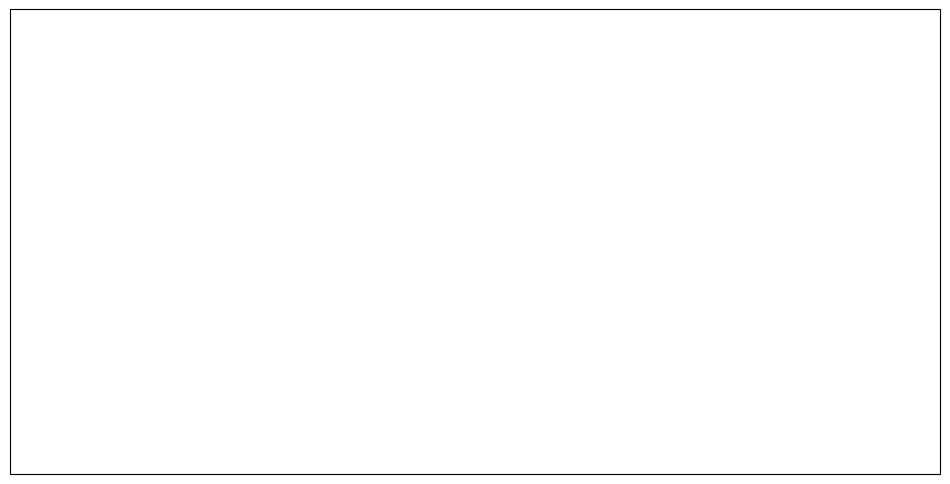

In [10]:
# Assuming ERA5 temperature variable is 't2m'
temp_era5 = era5_combined['t2m']  # replace with your var name
temp_gdnat = gdnat_combined  # if just 2D DataArray with time dim

temp_diff = temp_era5 - temp_gdnat

cc_mean = temp_diff.mean(dim='time')

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
cc_mean.plot(ax=ax, cmap='coolwarm', cbar_kwargs={'label': 'ERA5 - GDNat Temp (°C)'})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.set_title("Mean Temperature Difference (ERA5 - GDNat, 2000–2004)")
plt.show()


TypeError: No numeric data to plot.

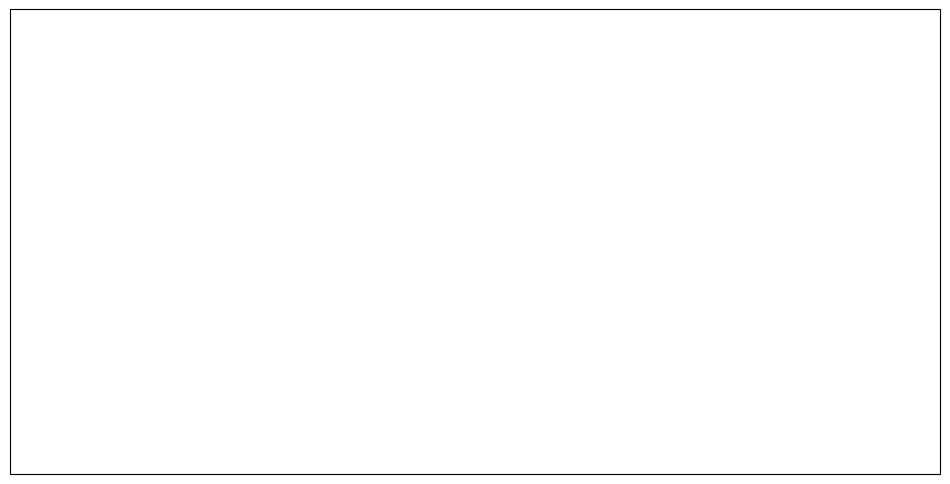

In [11]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

fig, ax = plt.subplots(figsize=(12, 8), subplot_kw={'projection': ccrs.PlateCarree()})
cc_mean.plot(ax=ax, cmap='coolwarm', cbar_kwargs={'label': 'ERA5 - GDNat Temp (°C)'})
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.add_feature(cfeature.STATES, linewidth=0.3)
ax.set_title("Mean Temperature Difference (ERA5 - GDNat, 2000–2004)")
plt.show()
